# Graph-based functional connectivity

Bulllmore&Sporns 2009 https://www.nature.com/articles/nrn2575

### Importing

In [2]:
import nilearn as nil
import nibabel as nib
import numpy as np
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as plt
from nilearn import plotting, surface, datasets, input_data, decomposition
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm # For having progressbar during loops
from nitime.timeseries import TimeSeries
from nitime.analysis import FilterAnalyzer
from sklearn.decomposition import PCA
from nilearn.connectome import ConnectivityMeasure
from matplotlib import colors
from matplotlib import patches
from pycirclize import Circos
import sys
import networkx as nx
import community as community_louvain

## Some utils

In [3]:
def signal_filter(nifti_img, mask, standardize=False, ub=0.08, lb=0.008):
    print('Filtering the signal...')
    img = nifti_img.get_fdata()
    img_affine = nifti_img.affine
    TR = nifti_img.header.get_zooms()[3]
    
    n_vox_mask = np.sum(mask==1) # Number of voxels in the mask
    mask_cord = np.where(mask==1)
    img_filtered = np.zeros(img.shape)
#     print(img_filtered.shape)
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = img[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        if standardize:
            tmp_TC_filt = (tmp_TC_filt-np.mean(tmp_TC_filt))/np.std(tmp_TC_filt)
            
        # Check if there are nan values
        if np.sum(np.isnan(tmp_TC_filt))!=0:
            for t in tmp_TC_filt:
                tmp_TC_filt[t] = 0
        img_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    return nib.Nifti1Image(img_filtered, img_affine)

In [4]:
# Undirected Graph metrics
def modularity_louvain(graph):
    # Detect the best partition
    partition = community_louvain.best_partition(graph, randomize=False)
    # Calculate modularity
    modularity_score = community_louvain.modularity(partition, graph)
    return modularity_score

def graph_metrics(METRIC, graph, n_nodes=360):
    edges_full = n_nodes*n_nodes
    if METRIC=='number_connected_components':
        metric = nx.number_connected_components(graph) # number of connected components
    elif METRIC=='size_giant_component':
        metric = len(sorted(nx.connected_components(graph), key=len, reverse=True)[0]) # size giant component
    elif METRIC=='average_shortest_path':
        GiantComponent = graph.subgraph(sorted(nx.connected_components(graph), key=len, reverse=True)[0]).copy()                    
        metric = nx.average_shortest_path_length(GiantComponent) # Average shortest path inside the giant component
    elif METRIC=='global_average_shortest_path':
        sps = [list(nx.shortest_path_length(graph.subgraph(cc).copy())) for cc in nx.connected_components(graph)]
        global_sps = []
        for sp in sps:
            for l in sp:
                global_sps += list(l[1].values())
        metric = np.mean(global_sps) # Average shortest path (global)
    elif METRIC=='fraction_of_edges':
        edges = graph.number_of_edges()
        metric = edges/edges_full # fraction of remaining edges inside the graph
    elif METRIC=='node_wih_link':
        nodes = len([n for n in graph.nodes if len(list(graph.neighbors(n))) > 0])
        metric = nodes/nodes_full # node with at least a link
    #                 centr = nx.betweenness_centrality(GiantComponent)
    #                 max_centr_key = max(centr, key=centr.get)
    #                 max_centr = centr[max_centr_key]
    #                 metric = max_centr
    #                 metric = nx.betweenness_centrality(graph)[node] # centrality of a selected node
    #             print(metric)
    elif METRIC=='degree_distribution':
        d = sorted((d for n, d in graph.degree() if d!=0), reverse=True) # degree distribution
    elif METRIC=='average_degree':
        metric = np.mean([d for n, d in graph.degree() if d!=0])
    elif METRIC=='average_local_efficiency':
        metric = nx.local_efficiency(graph)
    elif METRIC=='global_efficiency':
        metric = nx.global_efficiency(graph)
    elif METRIC=='local_efficiency':
        metric = [nx.global_efficiency(graph.subgraph(graph[v])) for v in graph]
    elif METRIC=='betweeness_centrality':
        metric = np.asarray(list(nx.betweenness_centrality(graph).values()))
    elif METRIC=='eigenvector_centrality':
        metric = np.asarray(list(nx.eigenvector_centrality(graph).values()))
    elif METRIC=='degree_centrality':
        metric = np.asarray(list(nx.degree_centrality(graph).values()))
    elif METRIC=='modularity':
        metric = modularity_louvain(graph)
    elif METRIC=='average_clustering':
        metric = nx.average_clustering(graph)
    elif METRIC=='clustering':
        metric = np.asarray(list(nx.clustering(graph).values()))
    # elif METRIC=='modularity_macroareas':
    #     metric = modularity_macroareas(graph, macro_areas_list)
    return metric

# Load an example subject

In [5]:
main_path='C:/Unito/PhD/CorsoFisica/data/rest_STD_clean/' # Path to the folder with the subjects

filelist = os.listdir(main_path) # List of the subjects

sub_ = nib.load(main_path+filelist[0]) # Load the nii.gz file of the subject
sub_header = sub_.header # Subject's header
sub_affine = sub_.affine # Subject's affine
sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
print(sub.shape) # x*y*z*time

TR = sub_.header.get_zooms()[3]

(52, 62, 52, 356)


# Load the brain mask

In [6]:
# main_path='E:/CorsoFisica/group_mask/' # Path to the folder with the subjects
main_path='C:/Unito/PhD/CorsoFisica/data/group_mask/' # Path to the folder with the subjects
filename='group_mask.nii.gz' # List of the subjects

group_mask_ = nib.load(main_path+filename) # Load the nii.gz file of the subject
group_mask_header = group_mask_.header # Subject's header
group_mask_affine = group_mask_.affine # Subject's affine
group_mask = group_mask_.get_fdata() # Get the numpy version of the nii.gz file
print(group_mask.shape) # x*y*z*time
n_vox_mask = np.sum(group_mask==1) # Number of voxels within the mask

(52, 62, 52)


# Load the atlas

In [7]:
which_atlas = 'glasser' # Chose the atlas
main_path='C:/Unito/PhD/CorsoFisica/data/atlas/' # Path to the folder with the subjects
filename = 'glasser_MNI152NLin6Asym_labels_p20_resamp.nii.gz'
atlas_labels_file = 'glasser_labels.csv'
delimiter = ','

atlas_ = nib.load(main_path+'/'+which_atlas+'/'+filename) # Load the nii.gz file of the subject
atlas_header = atlas_.header # Subject's header
atlas_affine = atlas_.affine # Subject's affine
atlas = atlas_.get_fdata() # Get the numpy version of the nii.gz file
print(atlas.shape) # x*y*z*time

# Labels
atlas_labels = pd.read_csv(main_path+'/'+which_atlas+'/'+atlas_labels_file, delimiter=delimiter)
print(atlas.min(), atlas.max())

# Define a mask based on the atlas
atlas_mask = np.zeros(atlas.shape)
atlas_mask[np.where(atlas!=0)] = 1
atlas_mask_ = nib.Nifti1Image(atlas_mask, atlas_affine)

(52, 62, 52)
0.0 360.0


In [8]:
atlas_labels

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,376,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,377,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,378,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,379,19,81.723096,153.990326,102.516324,827


# Compute a correlation matrix for each subject
Let's start with a single subject

In [9]:
%%time
sub_filtered_ = signal_filter(sub_, atlas_mask)
sub_filtered = sub_filtered_.get_fdata()
sub_parc = np.empty((0,sub.shape[-1])) # parcellized brain
for a_idx in range(1, int(atlas.max())+1): # Loop over areas
    area_coord = np.where(atlas==a_idx) # coordinates of the current brain region
    area_ts = sub[area_coord].mean(axis=0) # time series of the current region
    sub_parc = np.concatenate((sub_parc, area_ts[np.newaxis]), axis=0)
print(sub_parc.shape)

Filtering the signal...


100%|███████████████████████████████████████████████████████████████████████████████████████| 22143/22143 [00:11<00:00, 1991.31it/s]


(360, 356)
CPU times: total: 5.92 s
Wall time: 11.8 s


In [10]:
# Compute the correlation matrix
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([sub_parc.T])
print(correlation_matrix.shape)

(1, 360, 360)


In [11]:
# Setting to make a cool plot of the connectivity matrix
lobe_list = atlas_labels['Lobe'].unique()
lobe_sizes = []  # Number of regions in each group (left and right)
for hemi in ['L','R']:
    sub_atlas = atlas_labels.loc[atlas_labels['LR']==hemi]
    for lobe in lobe_list:
        size = len(sub_atlas.loc[sub_atlas['Lobe']==lobe])
        lobe_sizes.append(size)
print(lobe_sizes)
        
group_colors = ['red', 'blue', 'green', 'purple', 'gray']*2  # Colors for the group labels

# Cumulative sum of lobe sizes
cumsum_sizes = np.cumsum([0] + lobe_sizes)

[27, 67, 45, 35, 6, 20, 65, 51, 34, 10]


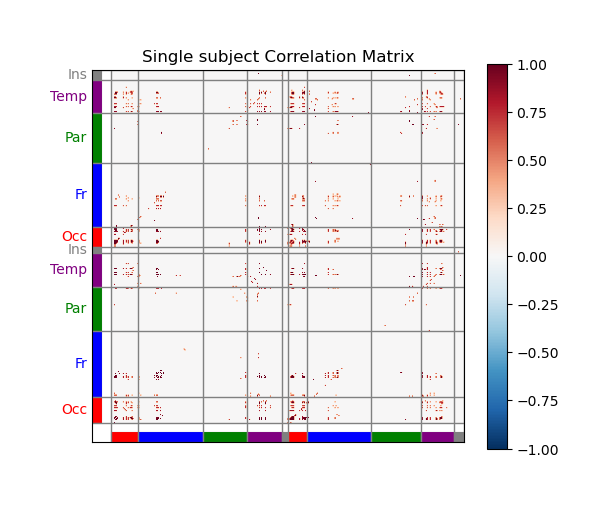

In [14]:
# Create a custom color bar for the groups
fig, ax = plt.subplots(figsize=(6, 5))
# cax = ax.imshow(correlation_matrix[0], vmin=-1, vmax=1, cmap='RdBu_r')

cax = ax.imshow(adj_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks([])
ax.set_yticks([])

# Color bar for the matrix
plt.colorbar(cax, ax=ax)
plt.xlim(-20, )
plt.ylim(-20, 360)

# Add dividing lines for each group
for size in cumsum_sizes:
    ax.axhline(size - 0.5, color='gray', linewidth=1)
    ax.axvline(size - 0.5, color='gray', linewidth=1)

# Add colored rectangles for each group - x axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((-20, cumsum_sizes[idx] - 0.5), 10, lobe_sizes[idx], linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)
    
# Add colored rectangles for each group - y axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((cumsum_sizes[idx] - 0.5, -20), lobe_sizes[idx], 10, linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)

# Annotate group names
for idx, label in enumerate(lobe_list.tolist()*2):
    plt.text(-25, (cumsum_sizes[idx] + cumsum_sizes[idx + 1]) / 2, label, fontsize=10, va='center', 
             ha='right', color=group_colors[idx])

plt.title('Single subject Correlation Matrix')
plt.show()

In [13]:
# Set an arbitrary threshold to binarize the correlation matrix in order to create a graph
threshold = 0.75
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=threshold)] = 1
adj_matrix[np.where(adj_matrix<threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [15]:
node_labels = atlas_labels['regionName'].values
n_nodes = len(node_labels)

In [16]:
# Make a matrix for pycirclize from adjacency matrix #
## Lobes version ##
# matrix_data = np.zeros((len(lobe_list),len(lobe_list)))
# for x_i, lobe_x in enumerate(lobe_list): # Loop over lobes
#     idxs_x = atlas_labels.loc[atlas_labels['Lobe']==lobe_x]['regionID'].index # Indexes of all the area of the current lobe
#     for y_i, lobe_y in enumerate([l for l in lobe_list if l!=lobe_x]): # Loop over lobes
#         idxs_y = atlas_labels.loc[atlas_labels['Lobe']==lobe_y]['regionID'].index # Indexes of all the area of the current lobe
#         # print(int(np.sum(adj_matrix[idxs_x][:,idxs_y])))
#         matrix_data[x_i,y_i] = int(np.sum(adj_matrix[idxs_x][:,idxs_y]))


## Corteces version ##
cortex_list = atlas_labels['cortex'].unique()
matrix_data = np.zeros((len(cortex_list),len(cortex_list)))
for x_i, cortex_x in enumerate(cortex_list): # Loop over cortices
    idxs_x = atlas_labels.loc[atlas_labels['cortex']==cortex_x]['regionID'].index # Indexes of all the area of the current cortex
    for y_i, cortex_y in enumerate([l for l in cortex_list if l!=cortex_x]): # Loop over cortices
        idxs_y = atlas_labels.loc[atlas_labels['cortex']==cortex_y]['regionID'].index # Indexes of all the area of the current cortex
        matrix_data[x_i,y_i] = int(np.sum(adj_matrix[idxs_x][:,idxs_y]))

np.fill_diagonal(matrix_data, 0)

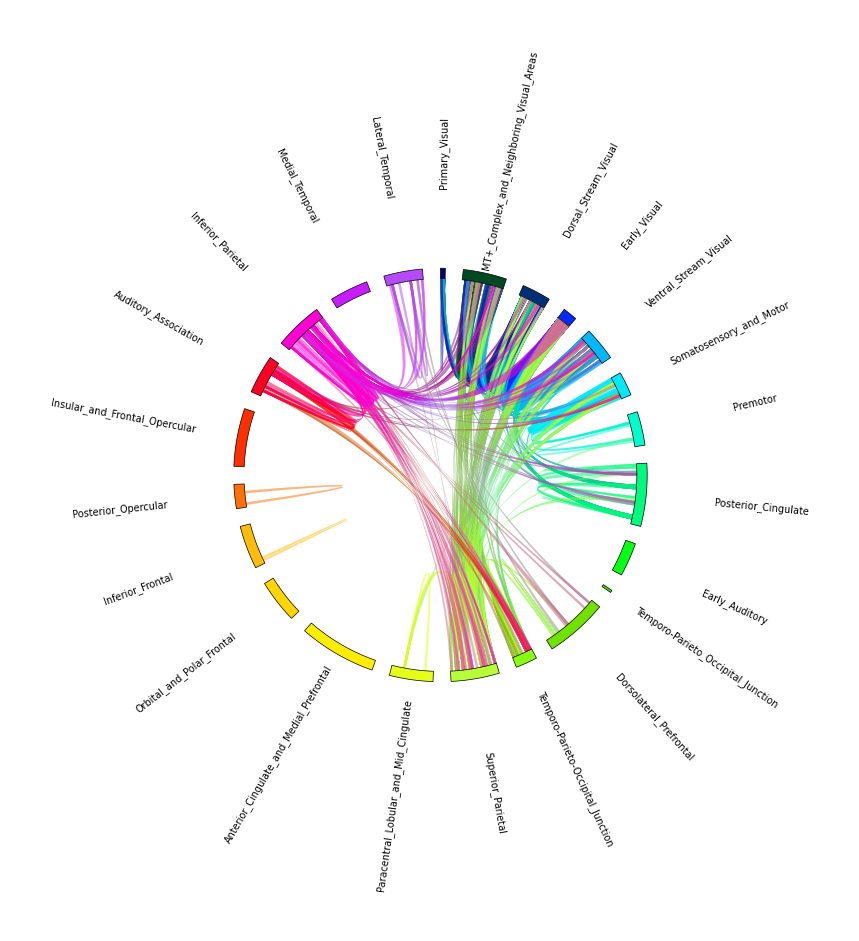

In [17]:
# Here we define each link, one by one

cortex_dict = {}
for cortex in cortex_list:
    cortex_dict[cortex] = int(np.sum(atlas_labels['cortex']==cortex))
cortex_cumsum = {}
prev=0
for cortex in cortex_dict.keys():
    cortex_cumsum[cortex]=prev
    prev+=cortex_dict[cortex]

# Use a pastel colormap from Matplotlib
cmap = plt.get_cmap('gist_ncar')

# Generate 23 unique pastel colors
colors = [cmap(i) for i in range(23*10)]

# Create a dictionary mapping each string to a pastel color
name2color = {cortex_list[i]: colors[i*10] for i in range(23)}
# find all the link 
links = []
for c_i,cortex in enumerate(cortex_list):
    idxs = atlas_labels[atlas_labels['cortex']==cortex].index # Indexes of all the regions in the current cortex
    for i,idx in enumerate(idxs): # Loop over all the regions in the current cortex
        for where in np.where(adj_matrix[idx])[0]: # loop over areas linked to the current area
            to_cortex = atlas_labels.iloc[where]['cortex']
            to_idx = np.where(atlas_labels[atlas_labels['cortex']==to_cortex].index==where)[0]
            from_idx = np.where(atlas_labels[atlas_labels['cortex']==cortex].index==idx)[0]
            links.append( [(cortex, from_idx[0], from_idx[0]+1 ), (to_cortex, to_idx[0], to_idx[0]+1), colors[c_i*10]] ) 

sectors = cortex_dict
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((95, 100))
    track.axis(fc=name2color[sector.name])
    track.text(sector.name, color="black", size=7, orientation='vertical', r=156,
               horizontalalignment='center', adjust_rotation=True, multialignment='right')
    # track.xticks_by_interval(1)

# Loop over all the links

# # Plot links in various styles
for link in links:
    circos.link(link[0], link[1], color=link[2], alpha=0.3)

circos.plotfig();

In [ ]:
# ### An alternative version to define the connectivity

# # Create matrix data (10 x 10)
# row_names = lobe_list
# # row_names = ['Occipital', 'Frontal', 'Parietal', 'Temporal', 'Insular']
# row_names = cortex_list
# col_names = row_names

# matrix_df = pd.DataFrame(matrix_data, index=row_names, columns=col_names)

# # Initialize from matrix (Can also directly load tsv matrix file)
# circos = Circos.initialize_from_matrix(
#     matrix_df,
#     space=3,
#     r_lim=(60, 68),
#     cmap='gist_ncar',
#     ticks_interval=None,
#     label_kws=dict(r=70, size=7, color="black", orientation='vertical'),
# )

# circos.plotfig();

# How to properly threshold a correlation matrix?

### Percolation

https://www.frontiersin.org/journals/neuroscience/articles/10.3389/fnins.2017.00441/full

In [18]:
%%time
# Compute the size of the giant component and the average shortest path for each at each treshold value

shortest_paths = [] # Average shortest path for each threshold
sizes_giant_component = []
thresholds = np.arange(0,1,0.05)
for thresh in tqdm(thresholds): # Loop over the thresolds for the phase locking matrices
    # Devo thresholdare pure la matrice media
    abs_correlation_matrix = np.abs(np.copy(correlation_matrix[0])) # Takes the module of the correlation matrix
    abs_correlation_matrix[np.where(abs_correlation_matrix<thresh)] = 0 # Binarize the mean pl matrix according to the current thresh
    abs_correlation_matrix[np.where(abs_correlation_matrix>=thresh)] = 1 # Binarize the mean pl matrix according to the current thresh
    G = nx.from_numpy_array(abs_correlation_matrix) # Make a graph with networkx
    shortest_paths.append(graph_metrics('average_shortest_path', G)) # Compute the average shortest path for the current threshold value
    sizes_giant_component.append(graph_metrics('size_giant_component', G)) # Compute the size (iin numebr of nodes) of the giant component

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:20<00:00,  1.04s/it]

CPU times: total: 12.4 s
Wall time: 20.8 s


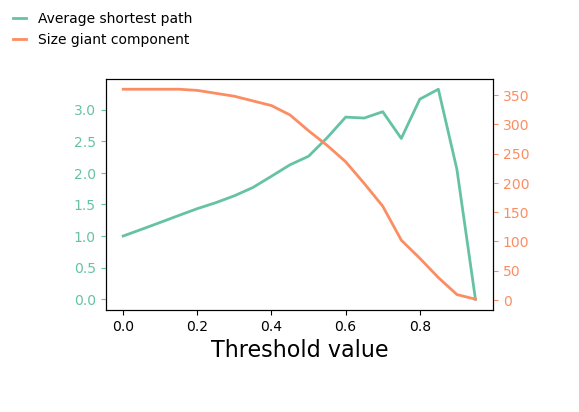

In [19]:
### Plot the results of the percolation analysis

cmap = matplotlib.colormaps['Set2']
colors = cmap(np.linspace(0, 1, 8))
fig, ax0 = plt.subplots(1, figsize=(5,3))
ax0.plot(thresholds, shortest_paths, alpha=1, linewidth=2, color=colors[0], label='Average shortest path')
ax0.set_xlabel('Threshold value', fontsize=16)
ax0.tick_params(colors=colors[0], axis='y')
ax1 = ax0.twinx()
ax1.plot(thresholds, sizes_giant_component, alpha=1, linewidth=2, color=colors[1],label='Size giant component')
ax1.yaxis.label.set_color(colors[1])
ax1.tick_params(colors=colors[1], axis='y')
fig.legend()

In [31]:
# # Set the optimal thrshold as the value corrisponding to the peak of the average shortest path as function of the thresold
opt_threshold = thresholds[np.argmax(shortest_paths)]
print(opt_threshold)
# # # Set the optimal thrshold as the value when the giant component starts breaking apart
opt_threshold = thresholds[np.where(np.asarray(sizes_giant_component)!=360)[0][0]]
print(opt_threshold)

0.8500000000000001
0.2


In [27]:
# Binarize the matrix
# opt_threshold = 0.5
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=opt_threshold)] = 1
adj_matrix[np.where(adj_matrix<opt_threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [ ]:
# %%time
# # Plot the obtained adjacency matrix (if there are to many links this cell will take a lot of time)

# # Use a pastel colormap from Matplotlib
# cmap = plt.get_cmap('gist_ncar')

# # Generate 23 unique pastel colors
# colors = [cmap(i) for i in range(23*10)]

# # find all the link 
# links = []
# for c_i,cortex in enumerate(cortex_list):
#     idxs = atlas_labels[atlas_labels['cortex']==cortex].index # Indexes of all the regions in the current cortex
#     for i,idx in enumerate(idxs): # Loop over all the regions in the current cortex
#         for where in np.where(adj_matrix[idx])[0]: # loop over areas linked to the current area
#             to_cortex = atlas_labels.iloc[where]['cortex']
#             to_idx = np.where(atlas_labels[atlas_labels['cortex']==to_cortex].index==where)[0]
#             from_idx = np.where(atlas_labels[atlas_labels['cortex']==cortex].index==idx)[0]
#             links.append( [(cortex, from_idx[0], from_idx[0]+1 ), (to_cortex, to_idx[0], to_idx[0]+1), colors[c_i*10]] ) 

# sectors = cortex_dict
# circos = Circos(sectors, space=5)
# for sector in circos.sectors:
#     track = sector.add_track((95, 100))
#     track.axis(fc=name2color[sector.name])
#     track.text(sector.name, color="black", size=7, orientation='vertical', r=156,
#                horizontalalignment='center', adjust_rotation=True, multialignment='right')
#     # track.xticks_by_interval(1)

# # Loop over all the links

# # # Plot links in various styles
# for link in links:
#     circos.link(link[0], link[1], color=link[2], alpha=0.1)
# # circos.link(("A", 1, 2), ("A", 7, 6), color="skyblue")
# # circos.link(("A", 9, 10), ("B", 4, 3), direction=1, color="tomato")
# # circos.link(("B", 5, 7), ("C", 6, 8), direction=1, ec="black", lw=1, hatch="//")
# # circos.link(("B", 18, 16), ("B", 11, 13), r1=90, r2=90, color="violet", ec="red", lw=2, ls="dashed")
# # circos.link(("C", 1, 3), ("B", 2, 0), direction=1, color="limegreen")
# # circos.link(("C", 11.5, 14), ("A", 4, 3), direction=2, color="chocolate", ec="black", lw=1, ls="

# circos.plotfig();

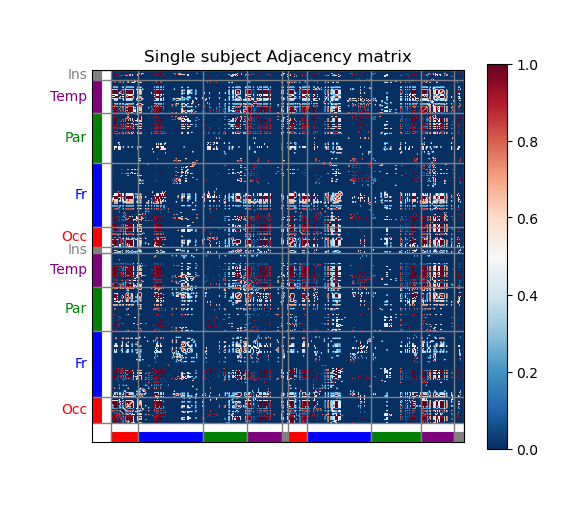

In [41]:
# Create a custom color bar for the groups
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(adj_matrix, vmin=0, vmax=1, cmap='RdBu_r')
ax.set_xticks([])
ax.set_yticks([])

# Color bar for the matrix
plt.colorbar(cax, ax=ax)
plt.xlim(-20, )
plt.ylim(-20, 360)

# Add dividing lines for each group
for size in cumsum_sizes:
    ax.axhline(size - 0.5, color='gray', linewidth=1)
    ax.axvline(size - 0.5, color='gray', linewidth=1)

# Add colored rectangles for each group - x axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((-20, cumsum_sizes[idx] - 0.5), 10, lobe_sizes[idx], linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)
    
# Add colored rectangles for each group - y axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((cumsum_sizes[idx] - 0.5, -20), lobe_sizes[idx], 10, linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)

# Annotate group names
for idx, label in enumerate(lobe_list.tolist()*2):
    plt.text(-25, (cumsum_sizes[idx] + cumsum_sizes[idx + 1]) / 2, label, fontsize=10, va='center', 
             ha='right', color=group_colors[idx])

plt.title('Single subject Adjacency matrix')
plt.show()

### "Integral" under all the possible thresholds

In [ ]:
###

## Global graph measures

In [67]:
opt_threshold = 0.5
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=opt_threshold)] = 1
adj_matrix[np.where(adj_matrix<opt_threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [68]:
G = nx.from_numpy_array(adj_matrix) # Make a graph with networkx

Text(0, 0.5, 'Frequency')

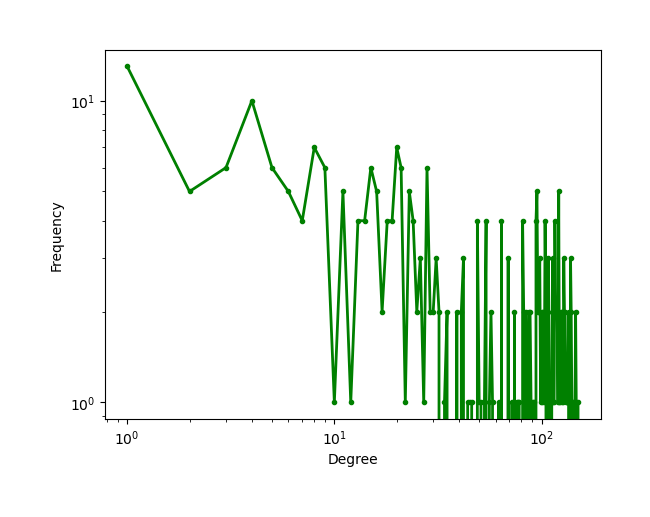

In [69]:
# Degree distribution
m=1
degree_freq = nx.degree_histogram(G)
degrees = range(len(degree_freq))
plt.figure() 
plt.loglog(degrees[m:], degree_freq[m:],'go-',linewidth=2) 
plt.xlabel('Degree')
plt.ylabel('Frequency')

In [70]:
nx.number_connected_components(G)

71

In [71]:
graph_metrics('global_efficiency',G)

0.3411389662643619

In [72]:
graph_metrics('average_shortest_path',G)

2.2623029603998464

In [73]:
graph_metrics('modularity',G)

0.22263839879280437

In [74]:
graph_metrics('average_clustering', G)

0.5667557129634618

## Local graph measures

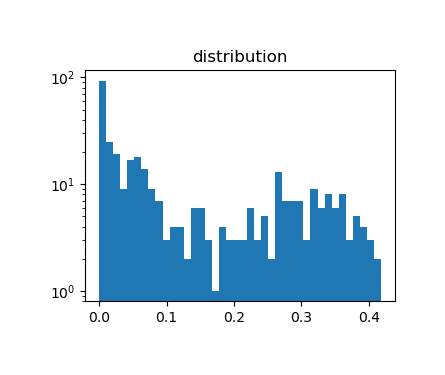

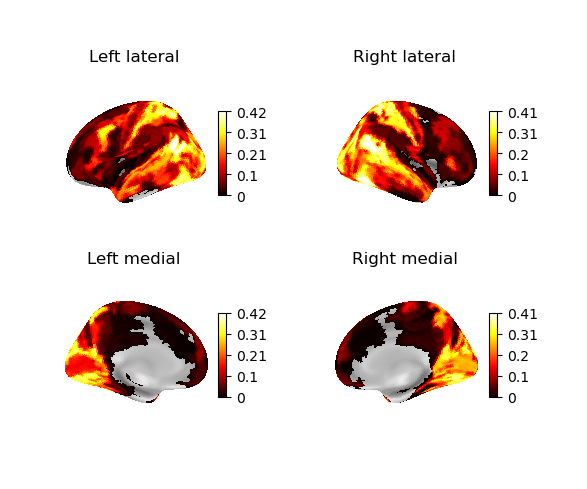

CPU times: total: 14.6 s
Wall time: 14.1 s


In [76]:
%%time
# Centrality measures - betweeness_centrality, clustering, local efficiency, degree_centrality
centralities = graph_metrics('degree_centrality',G)

# Plot the distribution of this measure across the brain
fig = plt.figure(figsize=(4,3))
plt.hist(centralities, bins=40);
plt.yscale('log')
plt.title('distribution')

brain_centralities = np.zeros((atlas.shape))
for area_i, area_c in enumerate(centralities):
    area_coord = np.where(atlas==area_i+1)
    brain_centralities[area_coord[0], area_coord[1], area_coord[2]] = area_c
nii_img = nib.Nifti1Image(brain_centralities, atlas_affine)

# Plot the betweenness centrality over the brain
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(nii_img, fsaverage.pial_left)
texture_left[np.where(texture_left==0)] = np.nan 
texture_right = surface.vol_to_surf(nii_img, fsaverage.pial_right)
texture_right[np.where(texture_right==0)] = np.nan 

cmap='hot'
fig, axs = plt.subplots(2,2,subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left lateral', colorbar=True, view='lateral', axes=axs[0][0], cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left medial', colorbar=True, view='medial', axes=axs[1][0], cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right lateral', colorbar=True, view='lateral', axes=axs[0][1], cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right medial', colorbar=True, view='medial', axes=axs[1][1], cmap=cmap)


# Show the plot
plotting.show()

## Multiple subjects

In [ ]:
###

# Community detection?

In [ ]:
###

# Weighted networks?